# PyMC-7 : Classification Bayesienne et Tests A/B

**Navigation** : [Index](../README.md) | [<< PyMC-6](PyMC-6-TrueSkill.ipynb) | [PyMC-8 >>](PyMC-8-Model-Selection.ipynb)

**Equivalent Infer.NET** : [Infer-7-Classification](../Infer/Infer-7-Classification.ipynb)

**Objectifs** :
- Implementer un modele de classification binaire (probit)
- Equivalence avec la Bayes Point Machine d'Infer.NET
- Realiser des tests A/B avec PyMC
- Comprendre l'impact de la taille d'echantillon
- Appliquer au CTR (Click-Through Rate)

In [1]:
try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import pytensor.tensor as pt
    PYTENSOR_AVAILABLE = True
except ImportError:
    PYTENSOR_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

if NUMPY_AVAILABLE and PYMC_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
else:
    print("PyMC n'est pas installe. Executez: pip install pymc arviz matplotlib numpy scipy")

PyMC version: 5.28.5


## 1. Bayes Point Machine (Probit)

La **Bayes Point Machine** d'Infer.NET classifie en utilisant un score lineaire.
En PyMC, on utilise un modele **probit** : P(y=1|x) = Phi(w*x - b) ou Phi est la CDF normale.

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Score lineaire | `Variable.InnerProduct(w, x)` | `poids * x_train - seuil` |
| Fonction lien | Infer.NET interne | `pm.math.invprobit` |
| Classification | `Variable.GaussianFromMeanAndVariance` | `pm.Bernoulli(p=invprobit(score))` |

In [2]:
# Donnees synthetiques : score d'entree vs admission
np.random.seed(42)
x_train = np.concatenate([np.random.normal(0.3, 0.15, 20), np.random.normal(0.7, 0.15, 20)])
y_train = np.concatenate([np.zeros(20), np.ones(20)])

# Modele Probit (equivalent Bayes Point Machine)
# P(y=1|x) = Phi(poids * x - seuil)
with pm.Model() as bpm:
    # Priors sur les parametres
    poids = pm.Normal('poids', mu=0, sigma=10)
    seuil = pm.Normal('seuil', mu=0, sigma=10)
    
    # Score lineaire
    score = poids * x_train - seuil
    
    # Fonction de lien probit
    p = pm.math.invprobit(score)
    
    # Vraisemblance
    y_obs = pm.Bernoulli('y_obs', p=p, observed=y_train)
    
    trace_bpm = pm.sample(3000, random_seed=42, return_inferencedata=True)

# Resultats
poids_post = trace_bpm.posterior['poids'].values.flatten()
seuil_post = trace_bpm.posterior['seuil'].values.flatten()
print(f"Poids posterior: {poids_post.mean():.2f} (std: {poids_post.std():.2f})")
print(f"Seuil posterior: {seuil_post.mean():.2f} (std: {seuil_post.std():.2f})")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [poids, seuil]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 31 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


Poids posterior: 12.24 (std: 3.36)
Seuil posterior: 5.76 (std: 1.64)


## 2. Frontiere de Decision

Visualisation de la frontiere de decision avec les incertitudes posterieures.

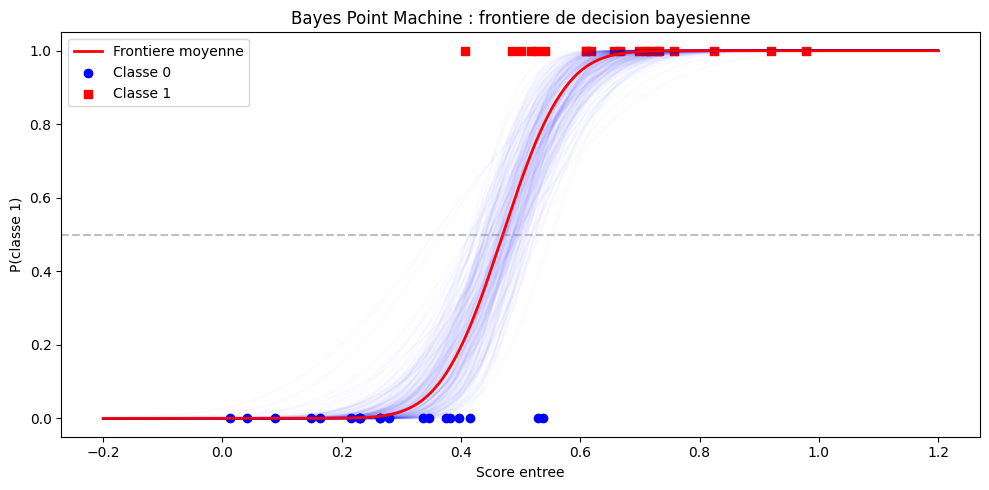

In [3]:
# Frontiere de decision avec bandes d'incertitude
x_grid = np.linspace(-0.2, 1.2, 200)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Echantillonner des frontieres depuis le posterior
n_samples = 200
indices = np.random.choice(len(poids_post), n_samples, replace=False)
for idx in indices:
    p_grid = stats.norm.cdf(poids_post[idx] * x_grid - seuil_post[idx])
    ax.plot(x_grid, p_grid, 'b-', alpha=0.02)

# Frontiere moyenne
p_mean = stats.norm.cdf(poids_post.mean() * x_grid - seuil_post.mean())
ax.plot(x_grid, p_mean, 'r-', linewidth=2, label='Frontiere moyenne')

# Donnees
ax.scatter(x_train[y_train == 0], y_train[y_train == 0], c='blue', marker='o', label='Classe 0')
ax.scatter(x_train[y_train == 1], y_train[y_train == 1], c='red', marker='s', label='Classe 1')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Score entree')
ax.set_ylabel('P(classe 1)')
ax.legend()
ax.set_title('Bayes Point Machine : frontiere de decision bayesienne')
plt.tight_layout()
plt.show()

## 3. Test A/B Bayesien

Le test A/B bayesien compare deux proportions (taux de clic, conversions, etc.).
Contrairement aux tests frequentistes, on obtient directement P(theta_B > theta_A).

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Taux A | `Variable.Beta(aA, bA)` | `pm.Beta('theta_a', a, b)` |
| Taux B | `Variable.Beta(aB, bB)` | `pm.Beta('theta_b', a, b)` |
| Difference | Inferer delta | `pm.Deterministic('delta', theta_b - theta_a)` |

In [4]:
# Test A/B : comparaison de deux versions d'une page
# Version A : 30 clics sur 100 visites
# Version B : 45 clics sur 120 visites

clicks_a, visits_a = 30, 100
clicks_b, visits_b = 45, 120

with pm.Model() as ab_test:
    # Priors : Beta(1, 1) = Uniforme (non informatif)
    theta_a = pm.Beta('theta_a', alpha=1, beta=1)
    theta_b = pm.Beta('theta_b', alpha=1, beta=1)
    
    # Vraisemblance
    obs_a = pm.Binomial('obs_a', n=visits_a, p=theta_a, observed=clicks_a)
    obs_b = pm.Binomial('obs_b', n=visits_b, p=theta_b, observed=clicks_b)
    
    # Difference (quantite d'interet)
    delta = pm.Deterministic('delta', theta_b - theta_a)
    
    trace_ab = pm.sample(3000, random_seed=42, return_inferencedata=True)

# Resultats
theta_a_post = trace_ab.posterior['theta_a'].values.flatten()
theta_b_post = trace_ab.posterior['theta_b'].values.flatten()
delta_post = trace_ab.posterior['delta'].values.flatten()

print(f"Taux A : {theta_a_post.mean():.3f} (95% CI: [{np.percentile(theta_a_post, 2.5):.3f}, {np.percentile(theta_a_post, 97.5):.3f}])")
print(f"Taux B : {theta_b_post.mean():.3f} (95% CI: [{np.percentile(theta_b_post, 2.5):.3f}, {np.percentile(theta_b_post, 97.5):.3f}])")
print(f"Delta (B - A) : {delta_post.mean():.3f}")
print(f"P(theta_B > theta_A) = {(delta_post > 0).mean():.3f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [theta_a, theta_b]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 29 seconds.


Taux A : 0.303 (95% CI: [0.218, 0.395])
Taux B : 0.377 (95% CI: [0.294, 0.464])
Delta (B - A) : 0.074
P(theta_B > theta_A) = 0.880


## 4. Impact de la Taille d'Echantillon

Plus l'echantillon est grand, plus l'incertitude diminue et la probabilite posterieure converge.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [ta, tb]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 34 seconds.


n= 10 : P(B>A) = 0.961


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [ta, tb]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 26 seconds.


n=500 : P(B>A) = 0.996


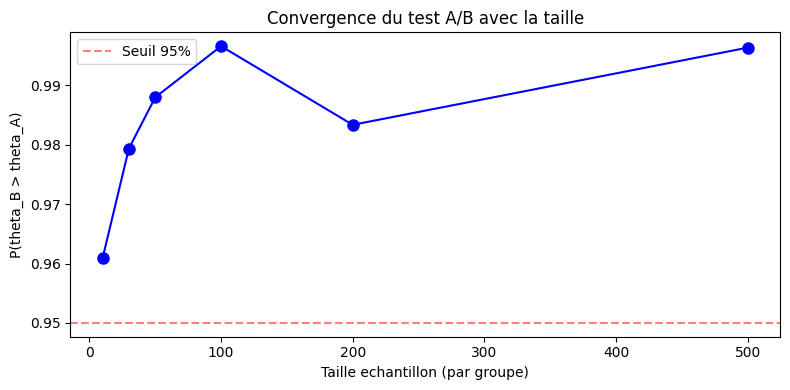

In [5]:
# Impact de la taille d'echantillon sur la certitude
sizes = [10, 30, 50, 100, 200, 500]
p_better = []

true_rate_a = 0.30
true_rate_b = 0.38

for n in sizes:
    np.random.seed(42)
    c_a = np.random.binomial(n, true_rate_a)
    c_b = np.random.binomial(n, true_rate_b)
    
    with pm.Model() as m:
        ta = pm.Beta('ta', 1, 1)
        tb = pm.Beta('tb', 1, 1)
        pm.Binomial('oa', n=n, p=ta, observed=c_a)
        pm.Binomial('ob', n=n, p=tb, observed=c_b)
        d = pm.Deterministic('d', tb - ta)
        t = pm.sample(2000, random_seed=42, return_inferencedata=True, progressbar=False)
    
    prob = (t.posterior['d'].values.flatten() > 0).mean()
    p_better.append(prob)
    print(f"n={n:3d} : P(B>A) = {prob:.3f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(sizes, p_better, 'bo-', markersize=8)
ax.axhline(0.95, color='red', linestyle='--', alpha=0.5, label='Seuil 95%')
ax.set_xlabel('Taille echantillon (par groupe)')
ax.set_ylabel('P(theta_B > theta_A)')
ax.set_title('Convergence du test A/B avec la taille')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Visualisation des Distributions A/B

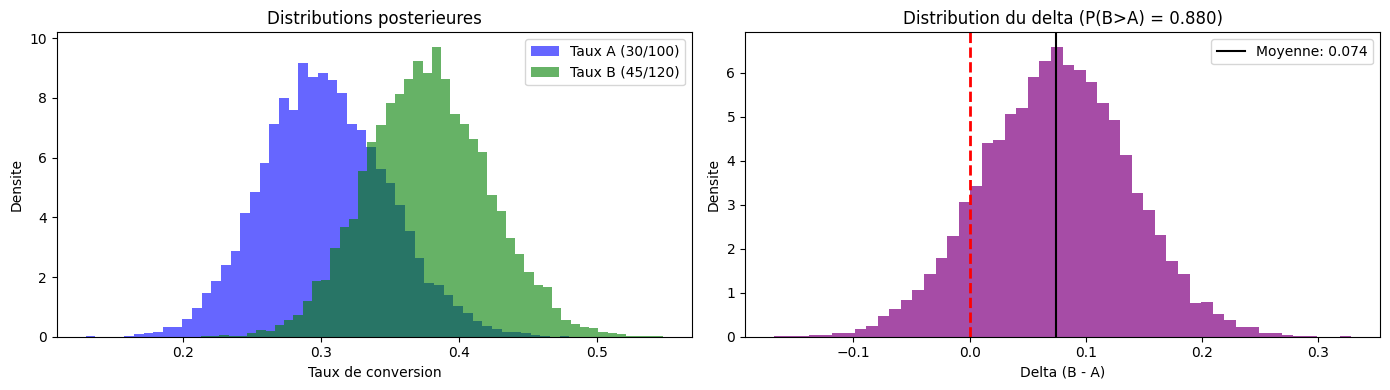

In [6]:
# Visualisation des distributions posterieures
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distributions theta_a et theta_b
x = np.linspace(0.1, 0.7, 200)
axes[0].hist(theta_a_post, bins=50, density=True, alpha=0.6, color='blue', label=f'Taux A ({clicks_a}/{visits_a})')
axes[0].hist(theta_b_post, bins=50, density=True, alpha=0.6, color='green', label=f'Taux B ({clicks_b}/{visits_b})')
axes[0].set_xlabel('Taux de conversion')
axes[0].set_ylabel('Densite')
axes[0].legend()
axes[0].set_title('Distributions posterieures')

# Distribution du delta
axes[1].hist(delta_post, bins=50, density=True, alpha=0.7, color='purple')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(delta_post.mean(), color='black', linestyle='-', label=f'Moyenne: {delta_post.mean():.3f}')
axes[1].set_xlabel('Delta (B - A)')
axes[1].set_ylabel('Densite')
axes[1].legend()
axes[1].set_title(f'Distribution du delta (P(B>A) = {(delta_post > 0).mean():.3f})')

plt.tight_layout()
plt.show()

## 6. Application : Click-Through Rate (CTR)

Un annonceur veut savoir si une nouvelle banniere a un meilleur CTR.
- Ancienne banniere : 150 clics sur 1000 impressions
- Nouvelle banniere : 180 clics sur 1000 impressions

La difference est-elle statistiquement significative ?

In [7]:
# CTR : test A/B pour bannieres publicitaires
with pm.Model() as ctr_test:
    theta_old = pm.Beta('theta_old', alpha=1, beta=1)
    theta_new = pm.Beta('theta_new', alpha=1, beta=1)
    
    obs_old = pm.Binomial('obs_old', n=1000, p=theta_old, observed=150)
    obs_new = pm.Binomial('obs_new', n=1000, p=theta_new, observed=180)
    
    delta_ctr = pm.Deterministic('delta_ctr', theta_new - theta_old)
    
    trace_ctr = pm.sample(3000, random_seed=42, return_inferencedata=True)

delta_ctr_post = trace_ctr.posterior['delta_ctr'].values.flatten()
theta_old_post = trace_ctr.posterior['theta_old'].values.flatten()
theta_new_post = trace_ctr.posterior['theta_new'].values.flatten()

print(f"CTR ancien : {theta_old_post.mean():.3f}")
print(f"CTR nouveau : {theta_new_post.mean():.3f}")
print(f"Amelioration : {delta_ctr_post.mean():.3f}")
print(f"P(nouveau > ancien) = {(delta_ctr_post > 0).mean():.3f}")
print(f"Lift relatif : {delta_ctr_post.mean() / theta_old_post.mean() * 100:.1f}%")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [theta_old, theta_new]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 26 seconds.


CTR ancien : 0.151
CTR nouveau : 0.181
Amelioration : 0.030
P(nouveau > ancien) = 0.964
Lift relatif : 19.7%


## 7. Comparaison Infer.NET vs PyMC pour la classification

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| Classification | Bayes Point Machine | Modele Probit/Logit |
| Score lineaire | `InnerProduct(w, x)` | `poids * x - seuil` |
| Test A/B | Message passing | MCMC (NUTS) |
| Resultat | Distribution analytique | Echantillons posterieur |
| P(A > B) | Calcul exact | `(delta > 0).mean()` |
| Scalabilite | Rapide (EP) | Plus lent mais general |

---

**Retour au sommaire** : [Index Probas](../README.md)

## Exercice : Classificateur de Spam

Implementer un classificateur de spam bayesien avec 3 features :
- x1 : frequence du mot "gratuit"
- x2 : presence de liens (0/1)
- x3 : longueur de l'objet (normalise)

Le modele : score = w1*x1 + w2*x2 + w3*x3 - seuil

**Indices** :
- Priors : `pm.Normal('w', mu=0, sigma=5, shape=3)` pour les poids
- Score : `pt.dot(X, w) - seuil`
- Lien : `pm.math.invprobit(score)`

In [8]:
# TODO etudiant : implementer le classificateur de spam bayesien
# Resultat attendu : poids posterieurs pour chaque feature + frontiere de decision

print("Exercice a completer")

Exercice a completer


---

**Retour au sommaire** : [Index Probas](../README.md)